# 09 — CGM Daily Means × Comorbidity Cluster × Study Group Interaction

**Purpose**: Test whether the glucose difference between comorbidity clusters
is consistent across study groups, or whether there is a significant
cluster × study-group interaction.

**Inputs** (from notebook 07):  
- `data/processed/features_with_cluster.csv`  
- `data/processed/cgm_aggregated.csv`

**Output**: `data/processed/09_cluster_x_study_group_summary.csv`


In [1]:
# ── 1. Environment Setup ───────────────────────────────────────────
import subprocess, sys

packages = ['azure-storage-blob', 'plotly', 'scipy', 'scikit-learn', 'seaborn']
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True, text=True)

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

STUDY_GROUP_ORDER = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
STUDY_GROUP_MAP   = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}
CLUSTER_MAP       = {0: 'Cardiometabolic', 1: 'Musculoskeletal-Inflammatory'}

# ── Mount Google Drive (persistent across independent kernels) ────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
out_dir = Path('/content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs')
out_dir.mkdir(parents=True, exist_ok=True)
print('Environment ready.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment ready.


In [2]:
# ── 2. Load Feature Files (outputs from notebook 07) ─────────────────────
features = pd.read_csv(out_dir / 'features_with_cluster.csv')
cgm      = pd.read_csv(out_dir / 'cgm_aggregated.csv')


# Derive study_group_label from code if missing (e.g. stale CSV from nb07)
if 'study_group_label' not in features.columns:
    features['study_group_label'] = features['study_group_code'].map(STUDY_GROUP_MAP)

if 'study_group_label' not in cgm.columns:
    cgm['study_group_label'] = cgm['study_group_code'].map(STUDY_GROUP_MAP)
features['study_group_label'] = pd.Categorical(
    features['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)
cgm['study_group_label'] = pd.Categorical(
    cgm['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)
features['cluster_label'] = features['comorbidity_cluster'].map(CLUSTER_MAP)

print(f'features: {features.shape}   cgm: {cgm.shape}')


features: (2245, 23)   cgm: (2245, 9)


## 3. Cross-tabulation Cell Counts

In [3]:
# ── 3. Cell counts — flag sparse cells (n < 30) ─────────────────────────
df = features.dropna(subset=['comorbidity_cluster', 'study_group_label', 'mean_glucose']).copy()
df['cluster_label'] = df['comorbidity_cluster'].map(CLUSTER_MAP)

cell_counts = df.groupby(['cluster_label', 'study_group_label'],
                          observed=True)['mean_glucose'].count().unstack()
print('=== Cell counts (rows=cluster, cols=study group) ===')
print(cell_counts.to_string())

sparse = [(c, g) for c in cell_counts.index for g in cell_counts.columns
          if cell_counts.loc[c, g] < 30]
if sparse:
    print('\n⚠️  Sparse cells (n<30):')
    for c, g in sparse:
        print(f'   {c} × {g}: n={cell_counts.loc[c, g]}')
else:
    print('\nAll cells adequately sized (n≥30).')


=== Cell counts (rows=cluster, cols=study group) ===
study_group_label             Healthy  Pre-DM  Oral Med  Insulin
cluster_label                                                   
Cardiometabolic                   220     218       334      147
Musculoskeletal-Inflammatory      541     334       347      104

All cells adequately sized (n≥30).


## 4. Visualisations

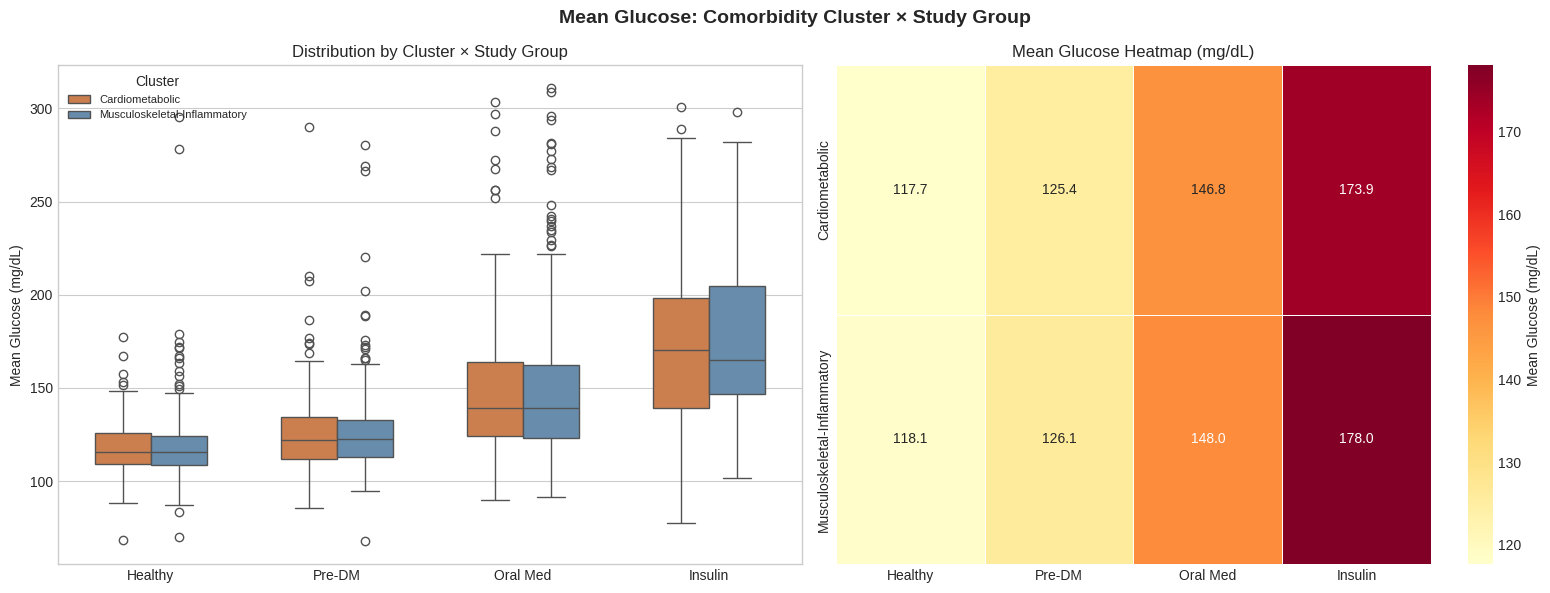

In [4]:
# ── 4a. Grouped boxplot + heatmap ────────────────────────────────────────
CLUSTER_ORDER = ['Cardiometabolic', 'Musculoskeletal-Inflammatory']
palette = {'Cardiometabolic': '#e07b39', 'Musculoskeletal-Inflammatory': '#5b8db8'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Mean Glucose: Comorbidity Cluster × Study Group', fontsize=14, fontweight='bold')

# Grouped boxplot
sns.boxplot(data=df, x='study_group_label', y='mean_glucose',
            hue='cluster_label', order=STUDY_GROUP_ORDER,
            hue_order=CLUSTER_ORDER, palette=palette, width=0.6, ax=axes[0])
axes[0].set_title('Distribution by Cluster × Study Group')
axes[0].set_xlabel('')
axes[0].set_ylabel('Mean Glucose (mg/dL)')
axes[0].legend(title='Cluster', fontsize=8)

# Heatmap of means
heat_data = (
    df.groupby(['cluster_label', 'study_group_label'], observed=True)['mean_glucose']
    .mean().unstack()
    .reindex(index=CLUSTER_ORDER, columns=STUDY_GROUP_ORDER)
)
sns.heatmap(heat_data, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[1], cbar_kws={'label': 'Mean Glucose (mg/dL)'})
axes[1].set_title('Mean Glucose Heatmap (mg/dL)')
axes[1].set_xlabel('')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


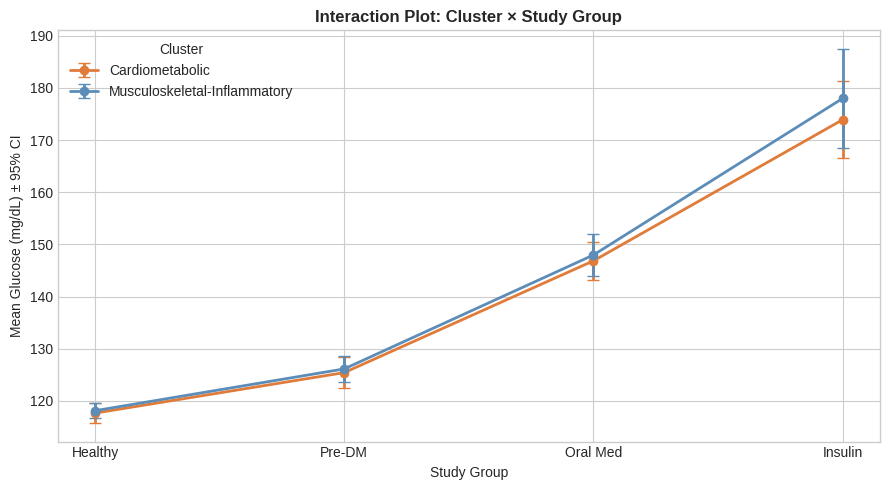

In [5]:
# ── 4b. Interaction plot (mean ± 95% CI) ─────────────────────────────────
cell_stats = (
    df.groupby(['study_group_label', 'cluster_label'], observed=True)['mean_glucose']
    .agg(mean='mean', std='std', n='count')
    .reset_index()
)
cell_stats['se']  = cell_stats['std'] / np.sqrt(cell_stats['n'])
cell_stats['ci95'] = 1.96 * cell_stats['se']

fig, ax = plt.subplots(figsize=(9, 5))
for cluster, grp_data in cell_stats.groupby('cluster_label'):
    grp_data = grp_data.set_index('study_group_label').reindex(STUDY_GROUP_ORDER)
    ax.errorbar(STUDY_GROUP_ORDER, grp_data['mean'], yerr=grp_data['ci95'],
                marker='o', linewidth=2, capsize=4,
                label=cluster, color=palette[cluster])
ax.set_title('Interaction Plot: Cluster × Study Group', fontweight='bold')
ax.set_xlabel('Study Group')
ax.set_ylabel('Mean Glucose (mg/dL) ± 95% CI')
ax.legend(title='Cluster')
plt.tight_layout()
plt.show()


## 5. Statistical Tests

In [6]:
# ── 5a. Within each study group: Mann-Whitney cluster comparison ─────────
print('=== Cluster comparison within each Study Group ===\n')
print(f'{"Study Group":<12}  {"Cluster0 mean":>13}  {"Cluster1 mean":>13}  {"U stat":>8}  {"p":>8}  sig')
print('-' * 75)

results = []
for grp in STUDY_GROUP_ORDER:
    sub = df[df['study_group_label'] == grp]
    c0  = sub[sub['comorbidity_cluster'] == 0]['mean_glucose'].dropna()
    c1  = sub[sub['comorbidity_cluster'] == 1]['mean_glucose'].dropna()
    if len(c0) > 5 and len(c1) > 5:
        u, p = stats.mannwhitneyu(c0, c1, alternative='two-sided')
        d    = (c0.mean() - c1.mean()) / np.sqrt((c0.std()**2 + c1.std()**2) / 2)
        sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'{grp:<12}  {c0.mean():>13.1f}  {c1.mean():>13.1f}  {u:>8.0f}  {p:>8.4f}  {sig}')
        results.append({'study_group': grp, 'n_c0': len(c0), 'n_c1': len(c1),
                        'mean_c0': round(c0.mean(),2), 'mean_c1': round(c1.mean(),2),
                        'U': u, 'p': round(p,5), 'cohens_d': round(d,3)})


=== Cluster comparison within each Study Group ===

Study Group   Cluster0 mean  Cluster1 mean    U stat         p  sig
---------------------------------------------------------------------------
Healthy               117.7          118.1     59357    0.9558  ns
Pre-DM                125.4          126.1     35915    0.7889  ns
Oral Med              146.8          148.0     58701    0.7697  ns
Insulin               173.9          178.0      7466    0.7541  ns


In [7]:
# ── 5b. Two-way Kruskal test (approximate interaction check) ─────────────
# Full interaction via permutation-based approach: compare effect size across groups
print('\n=== Effect magnitude (Cohens d, Cluster0−Cluster1) across study groups ===')
for r in results:
    bar = '█' * int(abs(r['cohens_d']) * 20)
    print(f"  {r['study_group']:<10}  d={r['cohens_d']:+.3f}  {bar}")
print()
print('Increasing |d| suggests the cluster × study-group interaction grows with severity.')



=== Effect magnitude (Cohens d, Cluster0−Cluster1) across study groups ===
  Healthy     d=-0.029  
  Pre-DM      d=-0.032  
  Oral Med    d=-0.031  
  Insulin     d=-0.086  █

Increasing |d| suggests the cluster × study-group interaction grows with severity.


## 6. Summary Table & Export

In [8]:
# ── 6. Summary export ────────────────────────────────────────────────────
summary = (
    df.groupby(['study_group_label', 'cluster_label'], observed=True)['mean_glucose']
    .agg(n='count', mean='mean', std='std', median='median')
    .round(2)
    .reset_index()
)
print(summary.to_string(index=False))

summary.to_csv(out_dir / '09_cluster_x_study_group_summary.csv', index=False)
print('\nSaved 09_cluster_x_study_group_summary.csv')


study_group_label                cluster_label   n    mean    std  median
          Healthy              Cardiometabolic 220 117.670 14.180 115.400
          Healthy Musculoskeletal-Inflammatory 541 118.130 17.140 115.800
           Pre-DM              Cardiometabolic 218 125.430 22.020 122.140
           Pre-DM Musculoskeletal-Inflammatory 334 126.140 22.610 122.810
         Oral Med              Cardiometabolic 334 146.850 34.140 139.270
         Oral Med Musculoskeletal-Inflammatory 347 147.970 37.930 139.100
          Insulin              Cardiometabolic 147 173.900 45.770 170.180
          Insulin Musculoskeletal-Inflammatory 104 177.980 49.260 164.980

Saved 09_cluster_x_study_group_summary.csv


## 7. Key Findings

- **No significant cluster effect within any study group**: All Mann-Whitney tests comparing Cardiometabolic vs. Musculoskeletal-Inflammatory within each disease stage were non-significant (all p > 0.75), indicating comorbidity cluster membership does not predict mean glucose once study group is accounted for.
- **Negligible effect sizes**: Cohen's d ranged from −0.029 (Healthy) to −0.086 (Insulin) — all below the conventional threshold for a small effect (0.2), with Musculoskeletal-Inflammatory trending marginally higher in the Insulin group.
- **No meaningful cluster × study-group interaction**: The cluster gap (Cardiometabolic − Musculoskeletal-Inflammatory) was essentially flat across disease stages, with mean differences of < 1 mg/dL in Healthy, Pre-DM, and Oral Med groups, and ~4 mg/dL in the Insulin group.
- **Heatmap**: The dominant pattern is disease severity (study group), not cluster — Insulin × Musculoskeletal-Inflammatory (178.0 mg/dL) and Insulin × Cardiometabolic (173.9 mg/dL) are both high, reflecting the study-group gradient from notebook 08.
- **Cell sizes**: All 8 cells were adequately sized (n ≥ 104), so no sparsity concerns apply.
- **Interpretation**: Comorbidity cluster (Cardiometabolic vs. Musculoskeletal-Inflammatory) does not appear to independently modulate glucose control. The study group (diabetes severity) is the primary driver of mean glucose differences in this cohort.
